In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, Subset
from sklearn.model_selection import train_test_split
import numpy as np
from numpy.fft import fft, fftfreq, fftshift

FS = 14e6

class DroneSignalsDataset(Dataset):
    def __init__(self, x_iq_tensor, x_spec_tensor, y_tensor, snr_tensor, duty_cycle_tensor):
        self.x_iq = x_iq_tensor
        self.x_spec = x_spec_tensor
        self.y = y_tensor
        self.snr = snr_tensor
        self.duty_cycle = duty_cycle_tensor

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x_iq[idx], self.x_spec[idx], self.y[idx], self.snr[idx], self.duty_cycle[idx]   


dataset_folder = './sig_data/'

dataset_stats = pd.read_csv(dataset_folder + 'class_stats.csv', index_col=0)
class_names = dataset_stats['class'].values

snr_stats = pd.read_csv(dataset_folder + 'SNR_stats.csv', index_col=0)
snr_list = snr_stats['SNR'].values

# load data
dataset_dict = torch.load(dataset_folder + 'dataset.pt')

x_iq = dataset_dict['x_iq']
x_spec = dataset_dict['x_spec']
y = dataset_dict['y']
snrs = dataset_dict['snr']
duty_cycle = dataset_dict['duty_cycle']


# create pytorch dataset form tensors
dataset = DroneSignalsDataset(x_iq,x_spec,y,snrs,duty_cycle)
del(x_iq, x_spec, y, snrs, duty_cycle, dataset_dict)

data_loader = torch.utils.data.DataLoader(
    dataset=dataset,
    batch_size=64,
    shuffle=True
)

feature explorations


In [ ]:
labels_all = dataset.y
classes, counts = torch.unique(labels_all, return_counts=True)
print("Class stats with num of samples")
for c, count in zip(classes, counts):
    print(f"Class {c.item()}: {count.item()} samples")


x_iq, x_spec, labels, snrs, duty_cycle =  next(iter(data_loader))

Class stats with num of samples
Class 0: 2194 samples
Class 1: 6938 samples
Class 2: 3661 samples
Class 3: 6481 samples
Class 4: 52552 samples
Class 5: 16546 samples
Class 6: 10333 samples


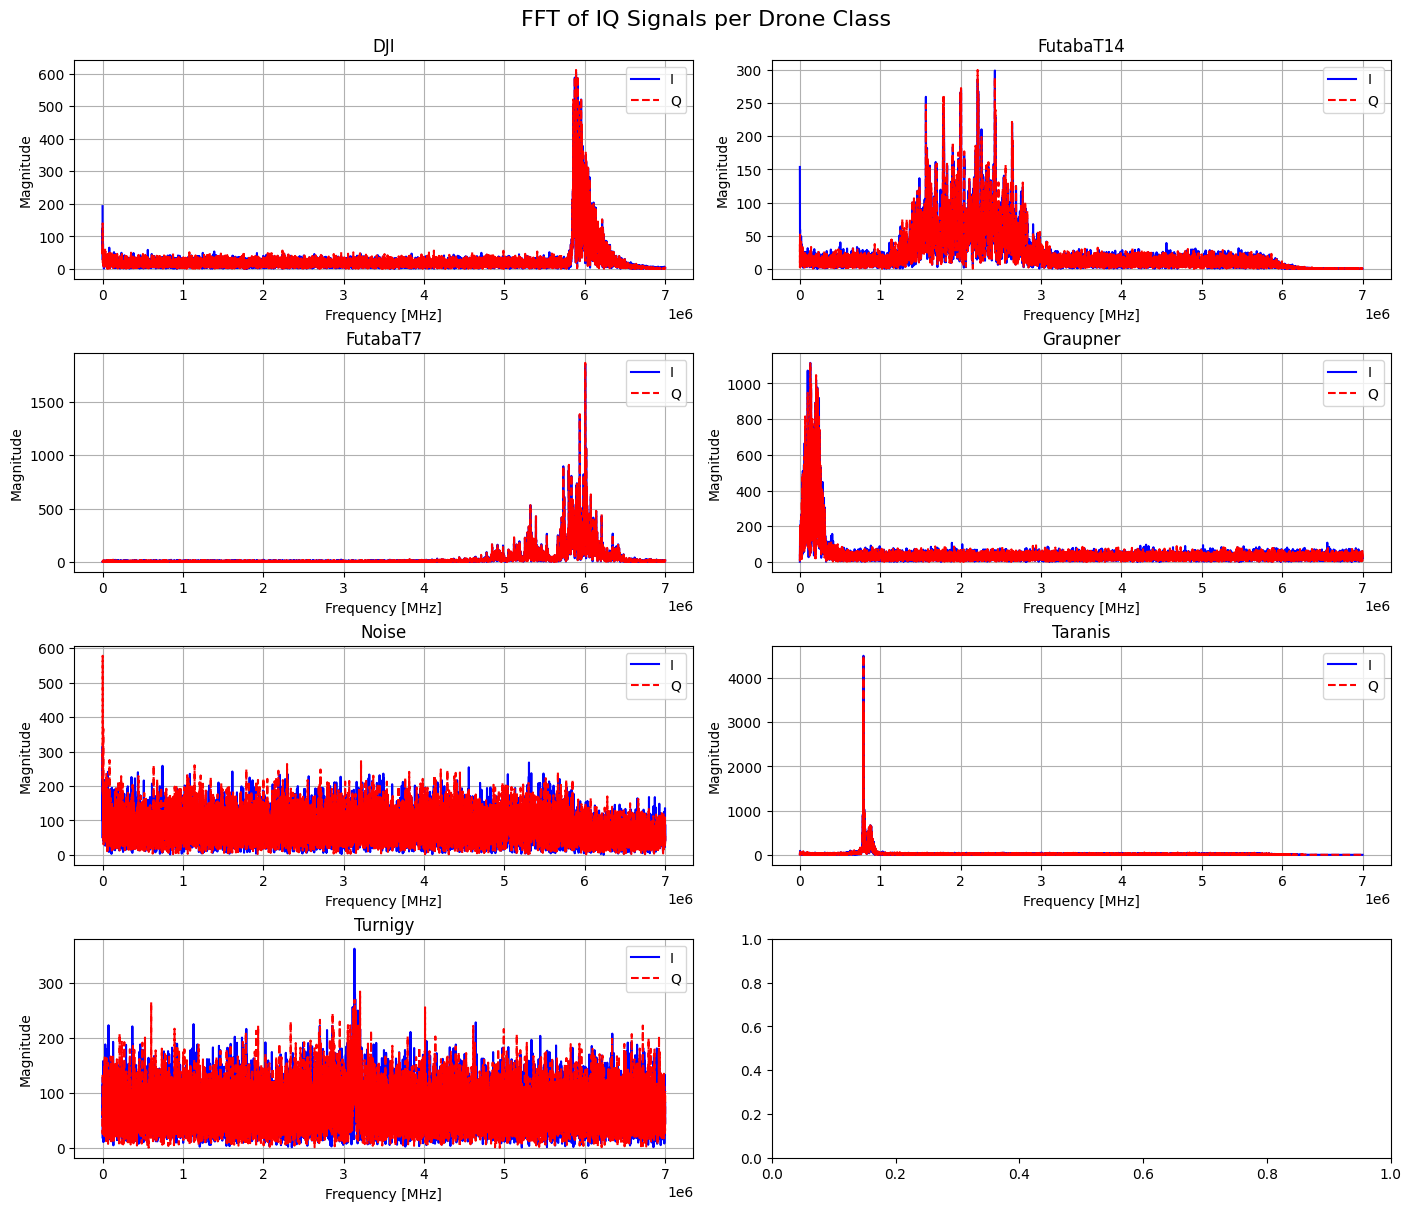

In [5]:
def plot_drone_data(spectrogram, iq, title, fs=1.0):
    figsize = (10,7)
    layout = [ [ 'spec_re', 'spec_im'],
                ['spec_re', 'spec_im' ], 
                ['iq_re', 'iq_re']]
    fig, axs = plt.subplot_mosaic(layout, figsize=figsize)
    

    fig.suptitle(title, fontsize=16)
    
    # plot spectrogram Re and Im
    spec_re = axs['spec_re'].imshow(spectrogram[0,:,:])
    axs['spec_re'].set_title('Re', fontsize=10)
    fig.colorbar(spec_re, ax=axs['spec_re'], location='right', shrink=0.5)

    spec_im = axs['spec_im'].imshow(spectrogram[1,:,:])
    axs['spec_im'].set_title('Im', fontsize=10)
    fig.colorbar(spec_im, ax=axs['spec_im'], location='right', shrink=0.5)

    # FFT
    N = iq.shape[1]
    Isig_ft = fft(iq[0,:])
    Qsig_ft = fft(iq[1,:])
    
    freqs = np.fft.fftfreq(N, d=1/fs)
    pos_idx = freqs >= 0
    freqs = freqs[pos_idx]

    Isig_ft = np.abs(Isig_ft[pos_idx])
    Qsig_ft = np.abs(Qsig_ft[pos_idx])


    axs['iq_re'].plot(freqs, np.abs(Isig_ft), label="I")
    axs['iq_re'].plot(freqs, np.abs(Qsig_ft), label="Q")
    axs['iq_re'].set_xlabel("Frequency [MHz]")
    axs['iq_re'].set_ylabel("Magnitude")
    axs['iq_re'].legend()
    axs['iq_re'].set_title("FFT of IQ signal")



def batch_plot(x_iq_batch, x_spec_batch, labels_batch, snrs_batch, duty_cycle_batch, fs=1.0):
    plotted_classes = set()
    classes_in_batch = labels_batch.unique()

    for i in range(labels_batch.size(0)):
        label = labels_batch[i].item()

        if label not in plotted_classes:
            x_iq = x_iq_batch[i].numpy()
            x_spec = x_spec_batch[i].numpy()
            snr = snrs_batch[i].item()
            duty = duty_cycle_batch[i].item()
            title = f"Class {class_names[label]} | SNR: {snr} | Duty cycle: {duty}"

            plot_drone_data(x_spec, x_iq, title, fs=fs)
            plotted_classes.add(label)

        if len(plotted_classes) == len(classes_in_batch):
            break

def plot_fft_per_class(x_iq_batch, labels_batch, fs=1.0):
    classes_in_batch = sorted(labels_batch.unique().tolist())
    n_classes = len(classes_in_batch)
    
    mosaic_layout = [
        ['c0', 'c1'],
        ['c2', 'c3'],
        ['c4', 'c5'],
        ['c6', 'c7']
    ]
    
    fig, axs = plt.subplot_mosaic(mosaic_layout, figsize=(14, 12), constrained_layout=True)
    fig.suptitle("FFT of IQ Signals per Drone Class", fontsize=16)
    
    plotted_classes = set()
    N = x_iq_batch.shape[2]  # number of samples
    
    for i in range(labels_batch.size(0)):
        label = labels_batch[i].item()
        if label not in plotted_classes:
            iq = x_iq_batch[i].numpy()
            I_fft = fft(iq[0,:])
            Q_fft = fft(iq[1,:])
            freqs = np.fft.fftfreq(N, d=1/fs)
            pos_idx = freqs >= 0
            freqs = freqs[pos_idx]
            I_fft = np.abs(I_fft[pos_idx])
            Q_fft = np.abs(Q_fft[pos_idx])
            
            subplot_name = f'c{classes_in_batch.index(label)}'
            ax = axs[subplot_name]
            ax.plot(freqs, I_fft, label="I", color='blue')
            ax.plot(freqs, Q_fft, '--', label="Q", color='red')
            ax.set_title(f"{class_names[label]}")
            ax.set_xlabel("Frequency [MHz]")
            ax.set_ylabel("Magnitude")
            ax.legend()
            ax.grid(True)
            
            plotted_classes.add(label)
        
        if len(plotted_classes) == n_classes:
            break
    
    # Hide unused subplots if fewer than 6 classes
    for idx in range(n_classes, 6):
        axs[f'c{idx}'].axis('off')
    
    plt.show()

plot_fft_per_class(x_iq, labels, fs=14e6 )
#batch_plot(x_iq, x_spec, labels, snrs, duty_cycle, fs=14e6)


## FFT Feature Extraction

features for ml are extracted by:

1. Combining I/Q components into a complex signal.
2. Computing the FFT and extracting magnitude and phase.
3. Downsampling magnitude and phase and adding summary statistics (mean, std, max, median, average).
   The resulting feature vector X_fft is ready for machine learning tasks.

In [ ]:
def extract_fft_features(x_iq):
    """
    Extracts FFT magnitude + phase features from an IQ signal.
    Input: x_iq shape (2, N) where [0]=I, [1]=Q
    """
    signal = x_iq[0,:] + 1j*x_iq[1,:]
    spectrum = fft(signal)[:len(signal)//2]
    mag = np.abs(spectrum)
    phase = np.angle(spectrum)

    feats = [
        np.mean(mag),
        np.std(mag),
        np.max(mag),
        np.median(mag),
        np.sum(mag) / len(mag)
    ]

    mag_ds = mag[::128]
    phase_ds = phase[::128]
    return np.concatenate([mag_ds, phase_ds, feats])

X_fft = np.array([extract_fft_features(x) for x in dataset.x_iq.numpy()])


In [7]:
snrs_np = dataset.snr.numpy().reshape(-1, 1)
duty_np = dataset.duty_cycle.numpy().reshape(-1, 1)
print(X_fft.shape)
print(snrs_np.shape)
print(duty_np.shape)

X = np.hstack([X_fft, snrs_np, duty_np])
y = dataset.y.numpy()

print("Feature matrix shape:", X.shape)

(98705, 133)
(98705, 1)
(98705, 1)
Feature matrix shape: (98705, 135)


## Training

radom forrest with automated Hyperparameter search

In [8]:
from sklearn.model_selection import train_test_split

# X = features, y = labels with 20% test_size
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

param_dist = {
    "n_estimators": [100, 200, 500],
    "max_depth": [10, 20, None],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", None]
}

code snippet bellow finds best hyperparameters via cv randomized search

In [ ]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    rf, param_distributions=param_dist, n_iter=15,
    cv=cv, scoring="accuracy", verbose=2, n_jobs=-1, random_state=42
)

search.fit(X_train, y_train)
best_rf = search.best_estimator_

print("Best parameters:", search.best_params_)
#Best parameters: {'n_estimators': 500, 'max_features': None, 'max_depth': 20, 'class_weight': None}

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END class_weight=None, max_depth=None, max_features=log2, n_estimators=100; total time= 1.5min
[CV] END class_weight=None, max_depth=None, max_features=log2, n_estimators=100; total time= 1.5min
[CV] END class_weight=None, max_depth=None, max_features=log2, n_estimators=100; total time= 1.5min
[CV] END class_weight=balanced, max_depth=20, max_features=log2, n_estimators=100; total time= 1.5min
[CV] END class_weight=None, max_depth=None, max_features=log2, n_estimators=100; total time= 1.5min
[CV] END class_weight=None, max_depth=None, max_features=log2, n_estimators=100; total time= 1.6min
[CV] END class_weight=None, max_depth=None, max_features=log2, n_estimators=200; total time= 2.8min
[CV] END class_weight=None, max_depth=None, max_features=log2, n_estimators=200; total time= 2.8min
[CV] END class_weight=None, max_depth=None, max_features=log2, n_estimators=200; total time= 2.9min
[CV] END class_weight=None, max_depth

trains random tree with the best found parameters and saves them with joblib

In [ ]:
from joblib import dump
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    max_depth=20,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)


['rforrest_model.joblib']

## Evaluation

Accuracy: 0.8237677929182918
              precision    recall  f1-score   support

         DJI       0.95      0.37      0.53       439
   FutabaT14       0.59      0.63      0.61      1388
    FutabaT7       0.79      0.31      0.44       732
    Graupner       0.48      0.44      0.45      1296
       Noise       1.00      1.00      1.00     10510
     Taranis       0.76      0.74      0.75      3309
     Turnigy       0.51      0.71      0.59      2067

    accuracy                           0.82     19741
   macro avg       0.73      0.60      0.63     19741
weighted avg       0.84      0.82      0.82     19741



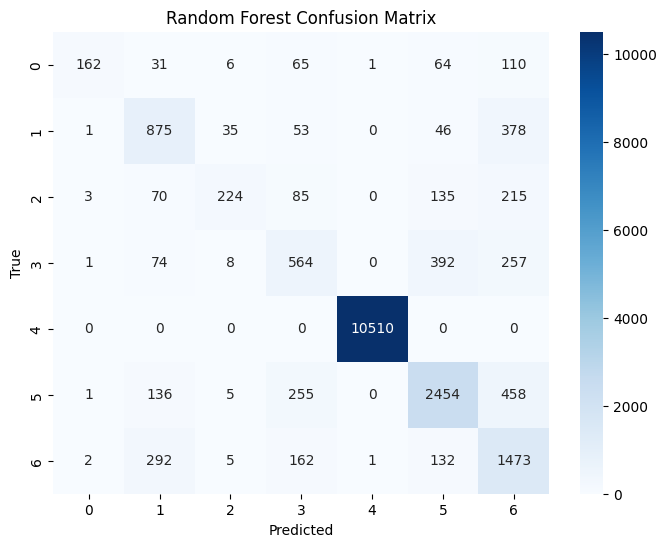

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from joblib import load

if not rf:
    rf = load("rforrest_model.joblib")



y_pred = rf.predict(X_test)
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Precision, Recall, F1-score
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Confusion Matrix")
plt.show()

10% improvement in accuracity was made thanks to the addition of snr and dutycycle and tuned parameters